In [ ]:
# -------------------- basic --------------------

from pathlib import Path
import os
import re
import math

# -------------------- arrays / tables --------------------

import numpy as np
import pandas as pd

# -------------------- plotting --------------------

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- scipy / stats --------------------

from scipy.stats import wilcoxon, spearmanr
from scipy.optimize import curve_fit

# -------------------- paths --------------------

from pathlib import Path
import sys
import importlib

project_root = Path.cwd().parent

config_path = project_root / "config"
library_path = project_root / "library"

for path in [config_path, library_path]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

# -------------------- neuprint --------------------

import neuprint

# -------------------- my libraries --------------------

import kylie_lib as cl
import lib_compare_receptor_to_neuprint_synapses as connectome
import lib_glucl_drive as glucl

from kylie_lib import syn_specs


In [11]:
results_dir = project_root / "results" / "connectome"
results_dir.mkdir(parents=True, exist_ok=True)

hemibrain_d7_names = pd.read_csv(results_dir / "hemibrainv121_d7_names.csv")
male_d7_names = pd.read_csv(results_dir / "malev09_d7_names.csv")

In [14]:
hemibrain_d7_names.head()

,id,instance,type,status,inputs (#post),outputs (#pre),#voxels
0,911911004,L1L9R8_R,Delta7,Traced,1496,653,1405984537
1,911919917,L1L9R8_R,Delta7,Traced,1182,562,1330959441
2,5813061383,L1L9R8_R,Delta7,Traced,1322,608,1252686779
3,911574261,L1L9R8_R,Delta7,Traced,1283,579,1331108352
4,881221166,L1L9R8_R,Delta7,Traced,1285,606,1392031704


In [ ]:
dataset_name = "hemibrainv1.2.1"
# dataset_name = "malev0.9"

data_dir = (
    project_root
    / "results"
    / "connectome"
    / dataset_name
    / "Delta7_per_cell"
)

csv_files = sorted(data_dir.glob("*.csv"))

all_d7_per_cell = {
    f.stem: pd.read_csv(f)
    for f in csv_files}

len(all_d7_per_cell)

42

In [24]:
# optional test
target_df = next(df for name, df in all_d7_per_cell.items() if "911578496" in name)
target_df["SynapseCount"].sum()

611

In [ ]:
# optional test
target_df_2 = next(df for name, df in all_d7_per_cell.items() if "911578496" in name)
target_df_2

,bodyId_pre,instance_pre,type_pre,SynapseCount
0,910796989,Delta7(PB15)_L5R4_L,Delta7,28
1,911129339,Delta7(PB15)_L4R5_R,Delta7,25
2,880875736,Delta7(PB15)_L5R4_L,Delta7,24
3,911241750,Delta7(PB15)_L6R4_L,Delta7,24
4,910442723,Delta7(PB15)_L4R5_R,Delta7,23
5,910783731,Delta7(PB15)_L8R1R9_L,Delta7,22
6,911470352,Delta7(PB15)_L2R7_R,Delta7,22
7,734581598,Delta7(PB15)_L6R3_L,Delta7,22
8,911574041,Delta7(PB15)_L2R7_R,Delta7,22
9,941814787,Delta7(PB15)_L6R3_L,Delta7,21


In [18]:
synapse_count_table = glucl.build_synapse_count_table(
    delta_name=hemibrain_d7_names,
    input_dict=all_d7_per_cell,
)

synapse_count_table

,id,instance,total_input,axonal_input,dendritic_input
0,911911004,L1L9R8_R,724,101,623
1,911919917,L1L9R8_R,554,98,456
2,5813061383,L1L9R8_R,644,95,549
3,911574261,L1L9R8_R,593,90,503
4,881221166,L1L9R8_R,611,71,540
5,911470352,L2R7_R,532,64,468
6,911574041,L2R7_R,567,57,510
7,942522378,L2R7_R,525,56,469
8,911578496,L2R7_R,611,72,539
9,911911699,L2R7_R,502,68,434


In [ ]:
check = (synapse_count_table["total_input"] ==
    synapse_count_table["axonal_input"]
    + synapse_count_table["dendritic_input"]
)
check.all()

True

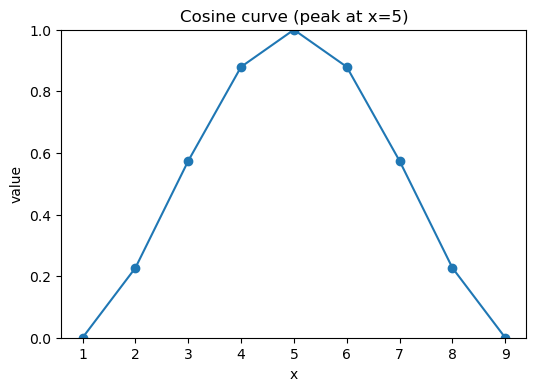

In [30]:
# x from 1 to 9
x = np.arange(1, 10)

# cosine with peak centered at x=5
y_raw = np.cos(2 * np.pi * (x - 5) / 9)

# normalize to range 0 → 1
y = (
    y_raw - y_raw.min()
) / (
    y_raw.max() - y_raw.min()
)

plt.figure(figsize=(6, 4))

plt.plot(
    x,
    y,
    marker="o",
)

plt.xticks(x)
plt.ylim(0, 1)

plt.xlabel("x")
plt.ylabel("value")
plt.title("Cosine curve (peak at x=5)")

plt.show()

In [37]:
synapse_count_table_add_bump = glucl.add_cosine_bump_columns(
    summary_df=synapse_count_table
)

synapse_count_table_add_bump

,id,instance,total_input,axonal_input,dendritic_input,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,...,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,911911004,L1L9R8_R,724,101,623,0.0,22.894841,57.971773,88.817909,101.0,...,0.0,623.0,531.763762,311.5,91.236238,0.0,91.236238,311.5,531.763762,623.0
1,911919917,L1L9R8_R,554,98,456,0.0,22.214796,56.249839,86.179754,98.0,...,0.0,456.0,389.220346,228.0,66.779654,0.0,66.779654,228.0,389.220346,456.0
2,5813061383,L1L9R8_R,644,95,549,0.0,21.534752,54.527905,83.541598,95.0,...,0.0,549.0,468.600811,274.5,80.399189,0.0,80.399189,274.5,468.600811,549.0
3,911574261,L1L9R8_R,593,90,503,0.0,20.401344,51.658016,79.144672,90.0,...,0.0,503.0,429.337355,251.5,73.662645,0.0,73.662645,251.5,429.337355,503.0
4,881221166,L1L9R8_R,611,71,540,0.0,16.094393,40.752435,62.436352,71.0,...,0.0,540.0,460.918831,270.0,79.081169,0.0,79.081169,270.0,460.918831,540.0
5,911470352,L2R7_R,532,64,468,0.0,14.507622,36.734589,56.280655,64.0,...,0.0,468.0,399.462987,234.0,68.537013,0.0,68.537013,234.0,399.462987,468.0
6,911574041,L2R7_R,567,57,510,0.0,12.920851,32.716743,50.124959,57.0,...,0.0,510.0,435.312229,255.0,74.687771,0.0,74.687771,255.0,435.312229,510.0
7,942522378,L2R7_R,525,56,469,0.0,12.694169,32.142765,49.245574,56.0,...,0.0,469.0,400.316540,234.5,68.683460,0.0,68.683460,234.5,400.316540,469.0
8,911578496,L2R7_R,611,72,539,0.0,16.321075,41.326413,63.315737,72.0,...,0.0,539.0,460.065278,269.5,78.934722,0.0,78.934722,269.5,460.065278,539.0
9,911911699,L2R7_R,502,68,434,0.0,15.414349,39.030501,59.798196,68.0,...,0.0,434.0,370.442172,217.0,63.557828,0.0,63.557828,217.0,370.442172,434.0


In [38]:
bump_cols = [
    c
    for c in synapse_count_table_add_bump.columns
    if c.startswith("axon_") or c.startswith("dendrite_")
]

synapse_count_table_add_bump_summary = pd.DataFrame(
    [
        synapse_count_table_add_bump[bump_cols].sum()
    ]
)

synapse_count_table_add_bump_summary

,axon_4_L,axon_3_L,axon_2_L,axon_1_L,axon_0,axon_1_R,axon_2_R,axon_3_R,axon_4_R,dendrite_4_L,dendrite_3_L,dendrite_2_L,dendrite_1_L,dendrite_0,dendrite_1_R,dendrite_2_R,dendrite_3_R,dendrite_4_R
0,0.0,628.361387,1591.066884,2437.65589,2772.0,2437.65589,1591.066884,628.361387,0.0,21704.0,18525.522789,10852.0,3178.477211,0.0,3178.477211,10852.0,18525.522789,21704.0


In [40]:
importlib.reload(glucl)

<module 'lib_glucl_drive' from '/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py'>

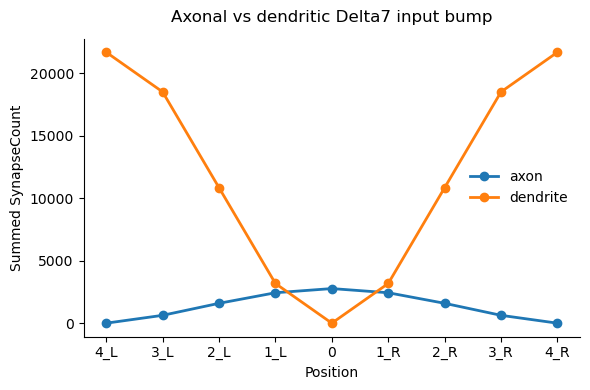

In [41]:
glucl.plot_axon_dendrite_bump_summary(
    synapse_count_table_add_bump_summary,
    title="Axonal vs dendritic Delta7 input bump",
    ylabel="Summed SynapseCount",
    #save_svg=results_dir / dataset_name / "Delta7_per_cell" / "axon_dendrite_bump_summary.svg",

)